# OpenBind-HIPPO

- **Target: D68EV3C**
- **Cycle: 01**

## Imports

In [5]:
%load_ext autoreload
%autoreload 2
import hippo
import mrich
from mrich import print
from pathlib import Path
from os import environ
import shutil
import molparse as mp
import pandas as pd
import plotly.express as px
from rdkit.Chem import PandasTools

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Config

In [2]:
target_name = "D68EV3C"
target_dir = Path(environ["BULK"]) / "TARGETS" / target_name
cycle_name = "cycle_01"
cycle_dir = Path(cycle_name)
aligned_dir = target_dir / "aligned_files"

## Animal

In [3]:
animal = hippo.HIPPO(target_name, target_dir / f"{target_name}.sqlite")

 Creating HIPPO animal

name = D68EV3C

db_path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite

DEBUG: hippo.Database.__init__()

DEBUG: Database.path = /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite

DEBUG: hippo.Database.connect()

DEBUG: sqlite3.version='2.6.0'

 Success  Database connected @ /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C.sqlite!

 Success  Initialised animal HIPPO("D68EV3C")!

In [40]:
animal.db.backup()

test

 DISK  Writing /opt/xchem-fragalysis-2/maxwin/BulkDock/TARGETS/D68EV3C/D68EV3C_1QNGV3Y.sqlite...

DEBUG: Copied 10000 of 330346 pages...

DEBUG: Copied 20000 of 330346 pages...

DEBUG: Copied 30000 of 330346 pages...

...

DEBUG: Copied 300000 of 330346 pages...

DEBUG: Copied 310000 of 330346 pages...

DEBUG: Copied 320000 of 330346 pages...

DEBUG: Copied 330000 of 330346 pages...

DEBUG: Copied 330346 of 330346 pages...

In [13]:
scaffolds = animal.compounds(tag="openbind_d68ev3c_c1_scaffolds_chemok_bbok")
elab_poses = scaffolds.elabs.poses
scaffolds, elab_poses

(compounds tagged openbind_d68ev3c_c1_scaffolds_chemok_bbok: {C × 77},
 {P × 231})

In [20]:
dedupe = set()
for pose in mrich.track(elab_poses):
    compound = pose.compound
    scaffolds = compound.scaffolds
    if len(scaffolds) != 1:
        mrich.warning("multiple", pose)
    scaffold = scaffolds[0]
    
    reference = pose.reference
    inspirations = pose.inspirations

    dedupe.add((scaffold.id, reference.id, tuple(inspirations.ids)))

    # elabs = scaffold.elabs

data = []

for scaffold_id, reference_id, inspiration_ids in dedupe:
    print(scaffold_id, reference_id, inspiration_ids)

    scaffold = animal.compounds[scaffold_id]
    reference = animal.poses[reference_id]
    inspirations = animal.poses[inspiration_ids]

    inspiration_d = dict()
    for i, name in enumerate(inspirations.names):
        inspiration_d[f"hit{i+1}"] = name
    
    for elab in mrich.track(scaffold.elabs):
        d = dict(smiles=elab.smiles)
        d.update(inspiration_d)
        data.append(d)

df = pd.DataFrame(data)
df.head()

Output()

33797 97
(44, 59)

Output()

30265 55
(106, 124)

Output()

46521 99
(98, 111)

Output()

,smiles,hit1,hit2
0,Cc1nn(CCNC(=O)CCc2c(C)[nH]c3ccccc23)cc1Cl,7gp2-a,7goy-a
1,Cc1[nH]c2ccccc2c1CCC(=O)NCCn1ncc(Cl)c1C,7gp2-a,7goy-a
2,Cc1c(Cl)cnn1CCNC(=O)CCc1cn(C)c2ccccc12,7gp2-a,7goy-a
3,Cc1nn(CCNC(=O)CCc2cn(C)c3ccccc23)cc1Cl,7gp2-a,7goy-a
4,Cc1ccc2[nH]cc(CCC(=O)NCCn3cc(Cl)c(C)n3)c2c1,7gp2-a,7goy-a


In [21]:
print(len(df))
df = df.drop_duplicates()
print(len(df))

1170

1170

In [22]:
df.to_csv("cycle_01/syndirella/elabs/d68ev3c_c1_elab_bulkdock_input.csv", index=False)
df

,smiles,hit1,hit2
0,Cc1nn(CCNC(=O)CCc2c(C)[nH]c3ccccc23)cc1Cl,7gp2-a,7goy-a
1,Cc1[nH]c2ccccc2c1CCC(=O)NCCn1ncc(Cl)c1C,7gp2-a,7goy-a
2,Cc1c(Cl)cnn1CCNC(=O)CCc1cn(C)c2ccccc12,7gp2-a,7goy-a
3,Cc1nn(CCNC(=O)CCc2cn(C)c3ccccc23)cc1Cl,7gp2-a,7goy-a
4,Cc1ccc2[nH]cc(CCC(=O)NCCn3cc(Cl)c(C)n3)c2c1,7gp2-a,7goy-a
...,...,...,...
1165,O=C(NC(Cc1c[nH]c2ccccc12)C(=O)N1CCC(n2cc(Cl)cn...,7gp2-a,7goy-a
1166,CCC(CNC(=O)C(Cc1c[nH]c2ccccc12)NC(=O)c1ccc(F)c...,7gp2-a,7goy-a
1167,Cc1nn(CCNC(=O)C(Cc2c[nH]c3ccccc23)NC(=O)c2ccc(...,7gp2-a,7goy-a
1168,COC(=O)C(Cc1cc[nH]n1)NC(=O)C1Cc2[nH]ncc2C(=O)N1,7go4-a,7gpo-a


In [11]:
# scaffold_poses = animal.poses(tag="openbind_d68ev3c_c1_scaffolds_chemok_bbok")
# elaborated_scaffolds = scaffold_poses.compounds.elabs.scaffolds
# scaffold_poses.compounds.elabs
# elaborated_scaffold_poses = animal.poses[set(elaborated_scaffolds.poses.ids).intersection(set(scaffold_poses.ids))]
# elaborated_scaffold_poses

## Add combined BB quote

In [29]:
pd.read_excel("../combined/Q2135669_2025-11(nov)-14-OpenBind-buildingblocks-c1(chempspace).xlsx").head()

,quote_entry,quoted_smiles,HIPPO Compound ID (xx01zvns2b),HIPPO Compound ID (a71ev2a),HIPPO Compound ID (d68ev3c),quote-1mg,quote-10mg
0,EN300-106689,Cl.Cl.Nc1ccc2c(c1)CNC2,61484.0,NaN,NaN,19,30
1,EN300-176585,O=C(O)c1cc(F)cc2[nH]nnc12,123049.0,NaN,NaN,30,48
2,EN300-1590558,N#Cc1c[nH]c2c(C(=O)O)cccc12,122834.0,NaN,NaN,14,19
3,EN300-26677505,CC(CN)c1ccncc1.Cl.Cl,618.0,NaN,NaN,33,55
4,EN300-6764593,COCc1ccc(Br)nc1,129215.0,NaN,NaN,14,24


In [66]:
animal.db.execute("DELETE FROM quote")
animal.db.commit()

In [64]:
animal.db.table_df("quote")

,quote_smiles,quote_amount,quote_supplier,quote_catalogue,quote_entry,quote_lead_time,quote_price,quote_currency,quote_purity,quote_date,quote_compound
quote_id,,,,,,,,,,,
1,O=C(O)CCc1c[nH]c2ccccc12,1.0,Enamine,None,EN300-20789,None,14.0,EUR,None,2025-12-01,97698
2,CC(C)C(CC(=O)O)c1c[nH]c2ccccc12,1.0,Enamine,None,EN300-231187,None,14.0,EUR,None,2025-12-01,98125
3,Cn1c2c(c3ccccc31)CC(C(=O)O)C2,1.0,Enamine,None,EN300-1725652,None,151.0,EUR,None,2025-12-01,98117
4,O=C(O)CCc1c[nH]c2ccccc12,1.0,Enamine,None,EN300-20789,None,14.0,EUR,None,2025-12-01,97698
5,CC(C)C(CC(=O)O)c1c[nH]c2ccccc12,1.0,Enamine,None,EN300-231187,None,14.0,EUR,None,2025-12-01,98125
...,...,...,...,...,...,...,...,...,...,...,...
72,COc1ccc(-c2[nH]c3ccccc3c2CCC(=O)O)c(OC)c1,1.0,Enamine,None,EN300-54683,None,15.0,EUR,None,2025-12-01,98168
73,O=C(O)CCc1c(-c2ccc(Cl)cc2)[nH]c2ccc(Cl)cc12,1.0,Enamine,None,EN300-376092,None,29.0,EUR,None,2025-12-01,98164
74,CC(C)(C)OC(=O)N[C@@H](Cc1c[nH]c2ccccc12)C(=O)O,1.0,Enamine,None,EN300-52850,None,14.0,EUR,None,2025-12-01,98158


In [67]:
q = animal.add_enamine_quote(
    "../combined/Q2135669_2025-11(nov)-14-OpenBind-buildingblocks-c1(chempspace).xlsx",
    orig_name_col = "HIPPO Compound ID (d68ev3c)",
    smiles_col = "quoted_smiles",
    entry_col = "quote_entry",
    fixed_amount = 1,
    price_col = "quote-1mg",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
    # supplier="Q2135669",
)
q

Output()

 Warning  SMILES changed during compound registration: c1cc(C2CCNC2)[nH]n1 --> c1cc(C2CCNC2)n[nH]1!

 Warning  SMILES changed during compound registration: NC(Cc1c[nH]cn1)C(=O)O --> NC(Cc1cnc[nH]1)C(=O)O!

{Ingredient × 58}

In [68]:
q = animal.add_enamine_quote(
    "../combined/Q2135669_2025-11(nov)-14-OpenBind-buildingblocks-c1(chempspace).xlsx",
    orig_name_col = "HIPPO Compound ID (d68ev3c)",
    smiles_col = "quoted_smiles",
    entry_col = "quote_entry",
    fixed_amount = 10,
    price_col = "quote-10mg",
    fixed_purity = None,
    fixed_lead_time = None,
    dry_run = False,
    currency = "EUR",
    allow_no_catalogue_col = True,
    orig_name_is_hippo_id=True,
    warn_nan_orig_name = False,
    overwrite_existing_quotes=False,
    delete_unavailable = False,
    debug = False,
    # supplier_name="MCule",
)
q

Output()

 Warning  SMILES changed during compound registration: c1cc(C2CCNC2)[nH]n1 --> c1cc(C2CCNC2)n[nH]1!

 Warning  SMILES changed during compound registration: NC(Cc1c[nH]cn1)C(=O)O --> NC(Cc1cnc[nH]1)C(=O)O!

{Ingredient × 58}

## Get GNINA scores

In [6]:
ref_sdf = "cycle_01/syndirella/elabs/openbind_d68ev3c_c1_elab_chemspace_filtered.sdf"
pdf = PandasTools.LoadSDF(ref_sdf)
pdf = pdf[["HIPPO Pose ID", "ID"]].rename(columns={"HIPPO Pose ID":"id", "ID":"name"}).iloc[1:].set_index("name")
pdf.head()

,id
name,
P6018,6018
P24064,24064
P42759,42759
P60973,60973
P60976,60976


In [8]:
sdf = pd.read_csv("cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_score.csv")
sdf.head()

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5
0,P6018,3.745,4.191,38.734,0.932,NaN
1,P24064,3.268,4.453,25.877,3.214,NaN
2,P42759,4.181,3.820,-2.648,3.969,NaN
3,P60973,4.668,4.539,-2.967,0.443,NaN
4,P60976,5.279,4.675,-4.311,1.177,NaN


In [9]:
sdf["pose_id"] = sdf["name"].apply(lambda x: int(pdf.loc[x, "id"]))
sdf = sdf.set_index("pose_id")
sdf

,name,gnina_score,gnina_score_min,smina_score_min,min_rmsd,Unnamed: 5
pose_id,,,,,,
6018,P6018,3.745,4.191,38.734,0.932,NaN
24064,P24064,3.268,4.453,25.877,3.214,NaN
42759,P42759,4.181,3.820,-2.648,3.969,NaN
60973,P60973,4.668,4.539,-2.967,0.443,NaN
60976,P60976,5.279,4.675,-4.311,1.177,NaN
...,...,...,...,...,...,...
63439,CNYZEMKPXABBAJ-UHFFFAOYSA-N-P59-P44-P59-607688,6.067,6.005,-4.195,1.411,NaN
63458,ZLZDJYFLLJIGSW-UHFFFAOYSA-N-P44-P44-P59-607688,6.567,5.965,-4.460,2.087,NaN
63489,RXJAPEMQJJZPKV-UHFFFAOYSA-N-P59-P44-P59-607688,6.143,5.741,-4.339,2.302,NaN


In [10]:
pose_ids = set()
for i,row in sdf.iterrows():
    pose = animal.poses[i]
    metadata = pose.metadata
    metadata.update({
        "gnina_score":row["gnina_score"],
        "gnina_score_min":row["gnina_score_min"],
        "smina_score_min":row["smina_score_min"],
        "rmsd(smina/fragmenstein)":row["min_rmsd"],
    })
    pose_ids.add(i)
    # break
scored_poses = animal.poses[pose_ids]
scored_poses.add_tag("openbind_d68ev3c_c1_elab_chemspace_filtered_scored")

Tagged {P × 219} w/ "openbind_d68ev3c_c1_elab_chemspace_filtered_scored"

## GNINA score distribution

In [11]:
scored_poses = animal.poses(tag="openbind_d68ev3c_c1_elab_chemspace_filtered_scored")
scored_poses

poses tagged "openbind_d68ev3c_c1_elab_chemspace_filtered_scored": {P × 219}

In [12]:
data = []
for pose in scored_poses:
    metadata = pose.metadata
    data.append({
        "pose_id":pose.id, 
        "gnina_score":metadata["gnina_score"],
        "gnina_score_min":metadata["gnina_score_min"],
        "smina_score_min":metadata["smina_score_min"],
        "rmsd(smina/fragmenstein)":metadata["rmsd(smina/fragmenstein)"],
    })
df = pd.DataFrame(data)

In [14]:
score_cutoff = df["gnina_score_min"].quantile(0.20)
score_cutoff

5.066

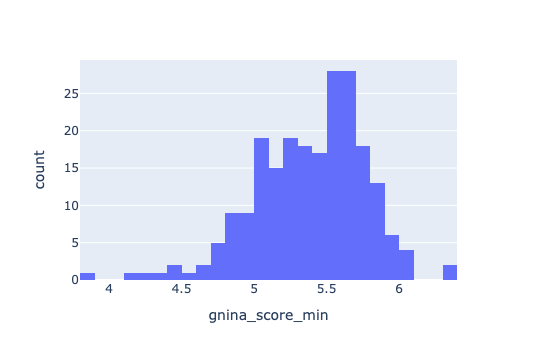

In [15]:
px.histogram(df, x="gnina_score_min")

In [16]:
filtered_scored_ids = df[df["gnina_score_min"] >= score_cutoff]["pose_id"].unique()

In [17]:
filtered_scored_poses = animal.poses[filtered_scored_ids]
filtered_scored_poses

{P × 176}

In [18]:
filtered_scored_poses.compounds

{C × 176}

## What is the cost of the filtered compounds?

In [69]:
recipe = hippo.Recipe.from_compounds(
    filtered_scored_poses.compounds, 
    # supplier="Enamine", 
    pick_cheapest=True,
    # use_routes=True,
    quoted_only=True,
    use_routes=False,
)
recipe

#compounds = 176

Output()

 Success  Found solution for compound=C98226!

 Success  Found solution for compound=C98230!

 ERROR  Reactants not available for reaction=R474: C98118 + C98186 -> C98238 via Amidation!

...

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 17.0 mg

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 12.0 mg

Recipe({Ingredient × 45} --> {Ingredient × 109} via {R × 109})

In [77]:
recipe.price

DEBUG: No quote available for C98182 with amount >= 11.0 mg. Estimating price...

DEBUG: No quote available for C98194 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C98198 with amount >= 17.0 mg. Estimating price...

DEBUG: No quote available for C98197 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C98199 with amount >= 12.0 mg. Estimating price...

€2007.60 EUR

In [71]:
recipe.write_json("cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_scored_top80percent_recipe.json")

DEBUG: No quote available with amount >= 11.0 mg

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 17.0 mg

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 12.0 mg

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/d68ev3c/cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_sc
ored_top80percent_recipe.json...

In [84]:
recipe.write_reactant_csv("cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_scored_top80percent_reactants.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

DEBUG: No quote available for C98182 with amount >= 11.0 mg. Estimating price...

DEBUG: No quote available for C98194 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C98198 with amount >= 17.0 mg. Estimating price...

DEBUG: No quote available for C98197 with amount >= 12.0 mg. Estimating price...

DEBUG: No quote available for C98199 with amount >= 12.0 mg. Estimating price...

 DISK  Writing cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_scored_top80percent_reactants.csv...

In [74]:
recipe.write_CAR_csv("cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_scored_top80percent_CAR.csv")

DEBUG: Querying database for routes

DEBUG: Assembling route dictionary

DEBUG: Checking availability

Output()

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/d68ev3c/cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_sc
ored_top80percent_CAR_1steps.csv...

 DISK  Writing 
/opt/xchem-fragalysis-2/maxwin/openbind-hippo/d68ev3c/cycle_01/gnina/openbind_d68ev3c_c1_elab_chemspace_filtered_sc
ored_top80percent_CAR.csv...

,target-names,no-steps,concentration-required-mM,amount-required-uL,batch-tag,reactant-1-1,reactant-2-1,reaction-product-smiles-1,reaction-name-1,reaction-recipe-1,reaction-groupby-column-1
0,C98852,1,None,None,None,O=C(O)CCc1c(-c2ccccc2)[nH]c2ccccc12,Cc1nn(CC(=O)NN)c(C)c1Cl,Cc1nn(CC(=O)NNC(=O)CCc2c(-c3ccccc3)[nH]c3ccccc...,Amidation,None,None
1,C98350,1,None,None,None,Cc1cccc2[nH]cc(CCC(=O)O)c12,NCCn1cc(Cl)c(C(F)(F)F)n1,Cc1cccc2[nH]cc(CCC(=O)NCCn3cc(Cl)c(C(F)(F)F)n3...,Amidation,None,None
2,C98339,1,None,None,None,Cc1ccc2[nH]cc(CCC(=O)O)c2c1,NCCn1cc(Cl)c(C(F)(F)F)n1,Cc1ccc2[nH]cc(CCC(=O)NCCn3cc(Cl)c(C(F)(F)F)n3)...,Amidation,None,None
3,C98863,1,None,None,None,O=C(O)CC(O)(c1c[nH]c2ccccc12)C(F)(F)F,Cc1nn(C(CN)C(C)C)c(C)c1Cl,Cc1nn(C(CNC(=O)CC(O)(c2c[nH]c3ccccc23)C(F)(F)F...,Amidation,None,None
4,C98353,1,None,None,None,Cc1[nH]c2ccccc2c1CCC(=O)O,CCC(CN)n1nc(C)c(Cl)c1Cl,CCC(CNC(=O)CCc1c(C)[nH]c2ccccc12)n1nc(C)c(Cl)c1Cl,Amidation,None,None
...,...,...,...,...,...,...,...,...,...,...,...
104,C98333,1,None,None,None,COc1ccc2c(CCC(=O)O)c[nH]c2c1,Cc1nn(CC(=O)NN)cc1Cl,COc1ccc2c(CCC(=O)NNC(=O)Cn3cc(Cl)c(C)n3)c[nH]c2c1,Amidation,None,None
105,C98335,1,None,None,None,Cc1ccc2[nH]cc(CCC(=O)O)c2c1,Cc1nn(CC(=O)NN)c(C)c1Cl,Cc1ccc2[nH]cc(CCC(=O)NNC(=O)Cn3nc(C)c(Cl)c3C)c2c1,Amidation,None,None
106,C98848,1,None,None,None,O=C(O)CCc1c(-c2ccccc2)[nH]c2ccccc12,NCCn1cc(Cl)c(C(F)(F)F)n1,O=C(CCc1c(-c2ccccc2)[nH]c2ccccc12)NCCn1cc(Cl)c...,Amidation,None,None
107,C98338,1,None,None,None,Cc1ccc2[nH]cc(CCC(=O)O)c2c1,Cc1nn(C(C)C(=O)NN)cc1Cl,Cc1ccc2[nH]cc(CCC(=O)NNC(=O)C(C)n3cc(Cl)c(C)n3...,Amidation,None,None


In [72]:
recipe.reactants.price_df

DEBUG: No quote available with amount >= 11.0 mg

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 17.0 mg

DEBUG: No quote available with amount >= 12.0 mg

DEBUG: No quote available with amount >= 12.0 mg

,compound_id,amount,quote_id,supplier,max_lead_time,quoted_amount,price,lead_time,quote_supplier
0,98122,6.0,75,None,None,10.0,€54.00 EUR,None,Enamine
1,98183,10.0,73,None,None,10.0,€22.00 EUR,None,Enamine
2,98124,5.0,76,None,None,10.0,€70.00 EUR,None,Enamine
3,98182,11.0,None,None,None,11.0,€25.30 EUR,None,Enamine
4,98125,4.0,60,None,None,10.0,€24.00 EUR,None,Enamine
5,98119,6.0,77,None,None,10.0,€59.00 EUR,None,Enamine
6,98188,2.0,81,None,None,10.0,€18.00 EUR,None,Enamine
7,98118,3.0,71,None,None,10.0,€57.00 EUR,None,Enamine
8,98191,4.0,80,None,None,10.0,€19.00 EUR,None,Enamine
9,98123,4.0,74,None,None,10.0,€39.00 EUR,None,Enamine
